# Ch09-3 LSTM과 GRU 셀


고급 순환층         
기본 순환층은 긴 시퀀스를 학슿바기 어려움   
    - 시퀀스가 길 수록 순환되는 은닉 상태에 담긴 정보가 점차 히석되기 때문 

## 1. LSTM의 구조 
ch09-3LSTM구조2.html 참조

## 2. LSTM신경망 훈련하기

In [27]:
# 훈련세트/검증세트 나누기 

from keras.datasets import imdb
from sklearn.model_selection import train_test_split

(train_input, train_target), (test_input, test_target) = imdb.load_data(num_words=500)

train_input, val_input, train_target, val_target = train_test_split(train_input, train_target, test_size=0.2, random_state=42)

In [28]:
#샘플 길이를 100으로 맞추고 패딩 추가하기
from keras.preprocessing.sequence import pad_sequences

train_seq = pad_sequences(train_input, maxlen=100)
val_seq = pad_sequences(val_input, maxlen=100)

In [29]:
#LSTM 셀을 사용한 순환층 만들기 (SimpleRNN -> LSTM)

import keras
model_lstm = keras.Sequential()
model_lstm.add(keras.layers.Input(shape=(100,)))
model_lstm.add(keras.layers.Embedding(500, 16))
model_lstm.add(keras.layers.LSTM(8))
model_lstm.add(keras.layers.Dense(1, activation='sigmoid'))

In [30]:
model_lstm.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 8)              │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,809 (34.41 KB)

 Trainable params: 8,809 (34.41 KB)

 Non-trainable params: 0 (0.00 B)

작은 셀이 4개 있으므로 4배인 800개가 됨 

In [31]:
#모델 컴파일, 훈련
model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-lstm-model.keras', save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
history = model_lstm.fit(train_seq, train_target, epochs=100, batch_size=64, validation_data=(val_seq, val_target), callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 0.5835 - loss: 0.6671 - val_accuracy: 0.7480 - val_loss: 0.5341
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.7651 - loss: 0.5040 - val_accuracy: 0.7870 - val_loss: 0.4544
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.7953 - loss: 0.4466 - val_accuracy: 0.7948 - val_loss: 0.4421
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.8050 - loss: 0.4210 - val_accuracy: 0.7954 - val_loss: 0.4372
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.8108 - loss: 0.4124 - val_accuracy: 0.7988 - val_loss: 0.4309
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.8181 - loss: 0.4098 - val_accuracy: 0.7990 - val_loss: 0.4281
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.8164 - loss: 0.3985 - val_accuracy: 0.8064 - val_loss: 0.4248
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - accuracy: 0.8230 - loss: 0

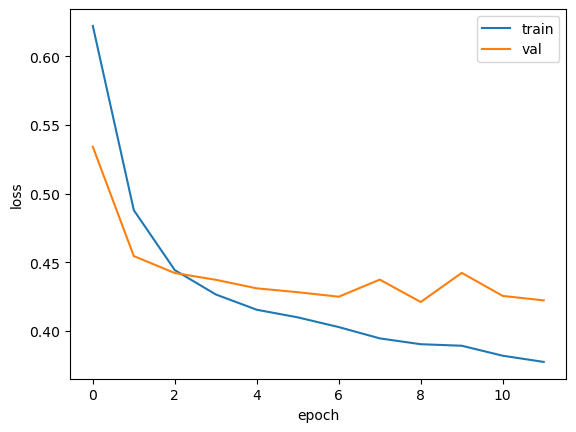

In [32]:
import matplotlib.pyplot as plt 

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

## 3. 순환층에 드롭아웃 적용하기

순환층은 자체적으로 드롭아웃 기능을 제공한다.       
- 드롭아웃은 은닉층에 있는 뉴런의 출력을 랜덤하게 꺼서 과대적합을 막는 기법.        

drop


In [33]:
model_dropout = keras.Sequential()
model_dropout.add(keras.layers.Input(shape=(100,)))
model_dropout.add(keras.layers.Embedding(500, 16))
model_dropout.add(keras.layers.LSTM(8, dropout=0.2))
model_dropout.add(keras.layers.Dense(1, activation='sigmoid'))

In [34]:
#훈련

model_dropout.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-dropout-model.keras', save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
history = model_dropout.fit(train_seq, train_target, epochs=100, batch_size=64, validation_data=(val_seq, val_target), callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.6130 - loss: 0.6500 - val_accuracy: 0.7652 - val_loss: 0.4964
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.7812 - loss: 0.4726 - val_accuracy: 0.7882 - val_loss: 0.4509
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.7994 - loss: 0.4372 - val_accuracy: 0.7982 - val_loss: 0.4420
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.8069 - loss: 0.4277 - val_accuracy: 0.8014 - val_loss: 0.4358
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.8054 - loss: 0.4238 - val_accuracy: 0.8064 - val_loss: 0.4350
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.8141 - loss: 0.4088 - val_accuracy: 0.7714 - val_loss: 0.4819
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.8076 - loss: 0.4138 - val_accuracy: 0.8004 - val_loss: 0.4287
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.8200 - loss: 0

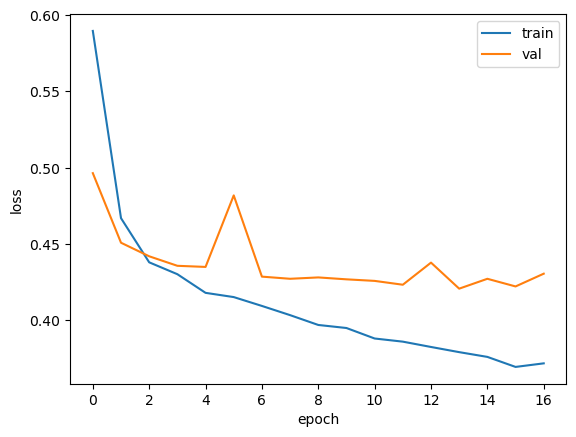

In [35]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

## 4. 2개의 층을 연결하기


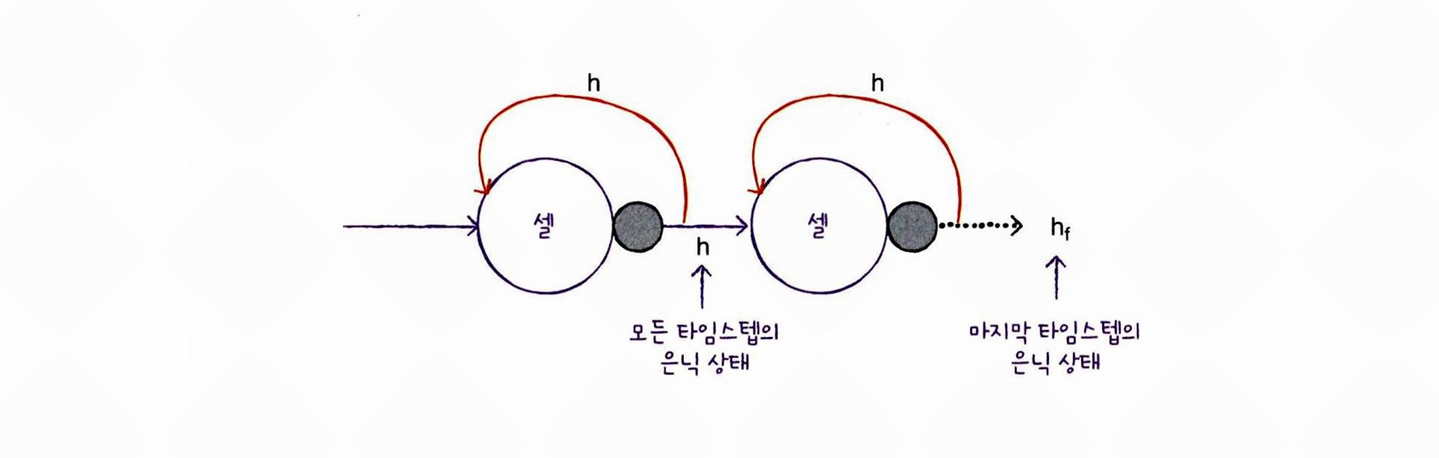

1. 상황 설정: 영화 리뷰 3단 분석팀      
우리가 영화 리뷰("이 영화 진짜 재미 없다")를 분석하기 위해 2개의 팀(Layer)을 꾸렸다고 칩시다.       
- 1팀(첫 번째 순환층): 단어 하나하나를 읽고 1차 분석을 합니다.        
- 2팀(두 번째 순환층): 1팀의 분석 결과를 받아서 더 깊게 생각합니다.       

2. 문제점: 1팀이 요약만 해버리면?       
만약 1팀이 문장 전체("이 영화 진짜 재미 없다")를 다 읽고 나서, **"그냥 부정적인 말이에요"**라고 달랑 한 마디(마지막 타임스텝의 은닉 상태)만 2팀에게 던져주면 어떻게 될까요?     

- 2팀의 불만: "아니, 나는 단어 순서대로 꼼꼼히 분석하는 팀인데, 왜 결론만 줘? '이' 다음에 '영화'가 오고, 그 다음에 '진짜'가 오는 그 **흐름(Sequence)**을 줘야 나도 분석을 하지!"      

- 순환 신경망은 시계열(순서가 있는) 데이터를 먹고 사는 친구들입니다. 2팀도 순환층이기 때문에 순서가 있는 데이터를 받아야 일을 할 수 있습니다.     

3. 해결책: return_sequences=True        
그래서 중간에 있는 1팀에게 이렇게 지시해야 합니다.          

- "야, 너네는 마지막 결론만 내지 말고, 단어 하나 읽을 때마다 나오는 실시간 생각(모든 타임스텝의 은닉 상태)을 전부 다 기록해서 2팀한테 넘겨!"      

- 이 명령어가 바로 코드로 칠 때 return_sequences=True입니다.      

4. 그림 해설        
이미지에 있는 그림을 이 비유에 대입해 보겠습니다.       

- 왼쪽 동그라미 (첫 번째 순환층):     
    화살표가 h라고 되어 있고 **"모든 타임스텝의 은닉 상태"**라고 써있죠?        
    이게 바로 1팀입니다. "이(h1), 영화(h2), 진짜(h3), 재미(h4), 없다(h5)" 각각에 대한 분석 결과를 줄줄이 소세지처럼 다 2팀에게 넘겨줍니다. (그래서 return_sequences=True 필요)      

- 오른쪽 동그라미 (두 번째 순환층):       
    화살표가 hf (Final) 하나만 있고 **"마지막 타임스텝의 은닉 상태"**라고 써있죠?       
    이게 2팀입니다. 2팀은 1팀이 준 줄줄이 소세지를 받아서 깊게 고민한 뒤, 최종적으로 "이 리뷰는 악플이다!" 라는 딱 하나의 결론만 내면 됩니다. (그래서 여기선 return_sequences=False 혹은 기본값 사용)       

요약                
순환층을 여러 개 쌓을 때: 뒷쪽 순환층도 "순서가 있는 데이터"가 필요하다.        

앞쪽 층의 임무: 데이터를 뭉개지 말고, 들어오는 족족 다 출력해서 뒷쪽 층에 넘겨줘야 한다. (return_sequences=True)        

마지막 층의 임무: 최종적으로 하나의 결론(예측값)만 내면 되므로, 맨 마지막 결과만 내보낸다. (return_sequences=False)     

In [36]:
model_2lstm = keras.Sequential()
model_2lstm.add(keras.layers.Input(shape=(100,)))
model_2lstm.add(keras.layers.Embedding(500, 16))
model_2lstm.add(keras.layers.LSTM(8, dropout=0.2, return_sequences=True))
model_2lstm.add(keras.layers.LSTM(8, dropout=0.2))
model_2lstm.add(keras.layers.Dense(1, activation='sigmoid'))
model_2lstm.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 100, 8)         │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 8)              │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,353 (36.54 KB)

 Trainable params: 9,353 (36.54 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
#모델 훈련
model_2lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-2lstm-model.keras', save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
history = model_2lstm.fit(train_seq, train_target, epochs=100, batch_size=64,
                          validation_data=(val_seq, val_target), 
                          callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 50ms/step - accuracy: 0.6130 - loss: 0.6446 - val_accuracy: 0.7624 - val_loss: 0.4996
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - accuracy: 0.7646 - loss: 0.4943 - val_accuracy: 0.7872 - val_loss: 0.4629
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.7850 - loss: 0.4603 - val_accuracy: 0.7722 - val_loss: 0.4737
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - accuracy: 0.8034 - loss: 0.4378 - val_accuracy: 0.7872 - val_loss: 0.4522
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 46ms/step - accuracy: 0.8118 - loss: 0.4177 - val_accuracy: 0.8002 - val_loss: 0.4315
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.8052 - loss: 0.4253 - val_accuracy: 0.8002 - val_loss: 0.4325
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - accuracy: 0.8065 - loss: 0.4250 - val_accuracy: 0.8022 - val_loss: 0.4252
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - accuracy: 0.8119 - loss: 0

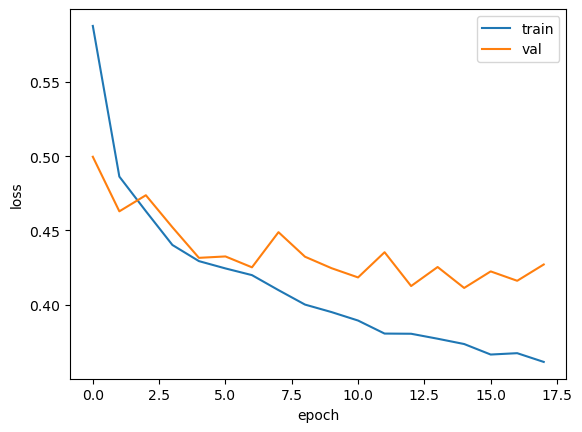

In [38]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

## 4. GRU 구조

Gated Recurrent Unit 의 약자        
**GRU(Gated Recurrent Unit)** 는 복잡했던 LSTM을 '미니멀리즘' 하게 바꾼 버전입니다. LSTM이 가지고 있던 2개의 기억 저장소(셀 상태, 은닉 상태)를 **단 하나(은닉 상태)** 로 합쳐버렸죠.

쉽게 비유하자면 **"멀티태스킹 하던 비서(LSTM)의 업무를 통합해서 한 번에 처리하는 스마트한 비서(GRU)"** 라고 생각하면 됩니다.

🚀 GRU의 2가지 핵심 게이트 (업무 분담)
GRU에는 딱 2개의 게이트가 있습니다. 이들이 서로 균형을 맞춰서 기억을 조절합니다.

1. "새로 쓸까, 말까?" (업데이트 게이트, z)
역할: 이전 기억을 얼마나 버리고, 새로운 정보를 얼마나 받아들일지 결정합니다.
LSTM과의 차이: LSTM은 "삭제 게이트(Forget)"와 "입력 게이트(Input)"가 따로 있었지만, GRU는 이걸 하나의 스위치로 합쳤습니다.
"새 정보를 70% 받아들이자"라고 결정하면, 자동으로 "그럼 옛날 기억은 30%만 남기자"가 됩니다. (자동 밸런스 조절)

2. "옛날 기억을 얼마나 참고할까?" (리셋 게이트, r)
역할: 새로운 정보를 처리하기 전에, 과거의 기억을 얼마나 '리셋'하고 볼지 결정합니다.
비유: 새 프로젝트를 시작할 때, "이전 프로젝트 자료를 다 지우고 백지에서 시작할까(리셋), 아니면 참고하면서 할까?"를 정하는 것과 같습니다.

📊 그림으로 이해하는 구조       
$W_z$ (업데이트 게이트):

그림의 맨 왼쪽 보라색 동그라미입니다.

이 값이 크면 "새 정보 위주로 가자!", 작으면 "옛날 기억 유지하자!"가 됩니다.

$W_r$ (리셋 게이트):

그림의 가운데 빨간색 동그라미입니다.

이 값이 0에 가까우면 "과거는 잊어!($h_{t-1}$ 무시)"라고 명령합니다.

통합된 상태 ($h$):

LSTM처럼 위아래로 나뉘어 흐르지 않고, 하나의 선($h$)만 흐릅니다. 구조가 훨씬 단순해서 계산이 빠릅니다.

💡 한 줄 요약
"LSTM: 기억 지우기 버튼 따로, 입력 버튼 따로 있어서 복잡함."
"GRU: 시소처럼 '입력'을 늘리면 자동으로 '삭제'가 되도록 하나로 합쳐서 심플함."

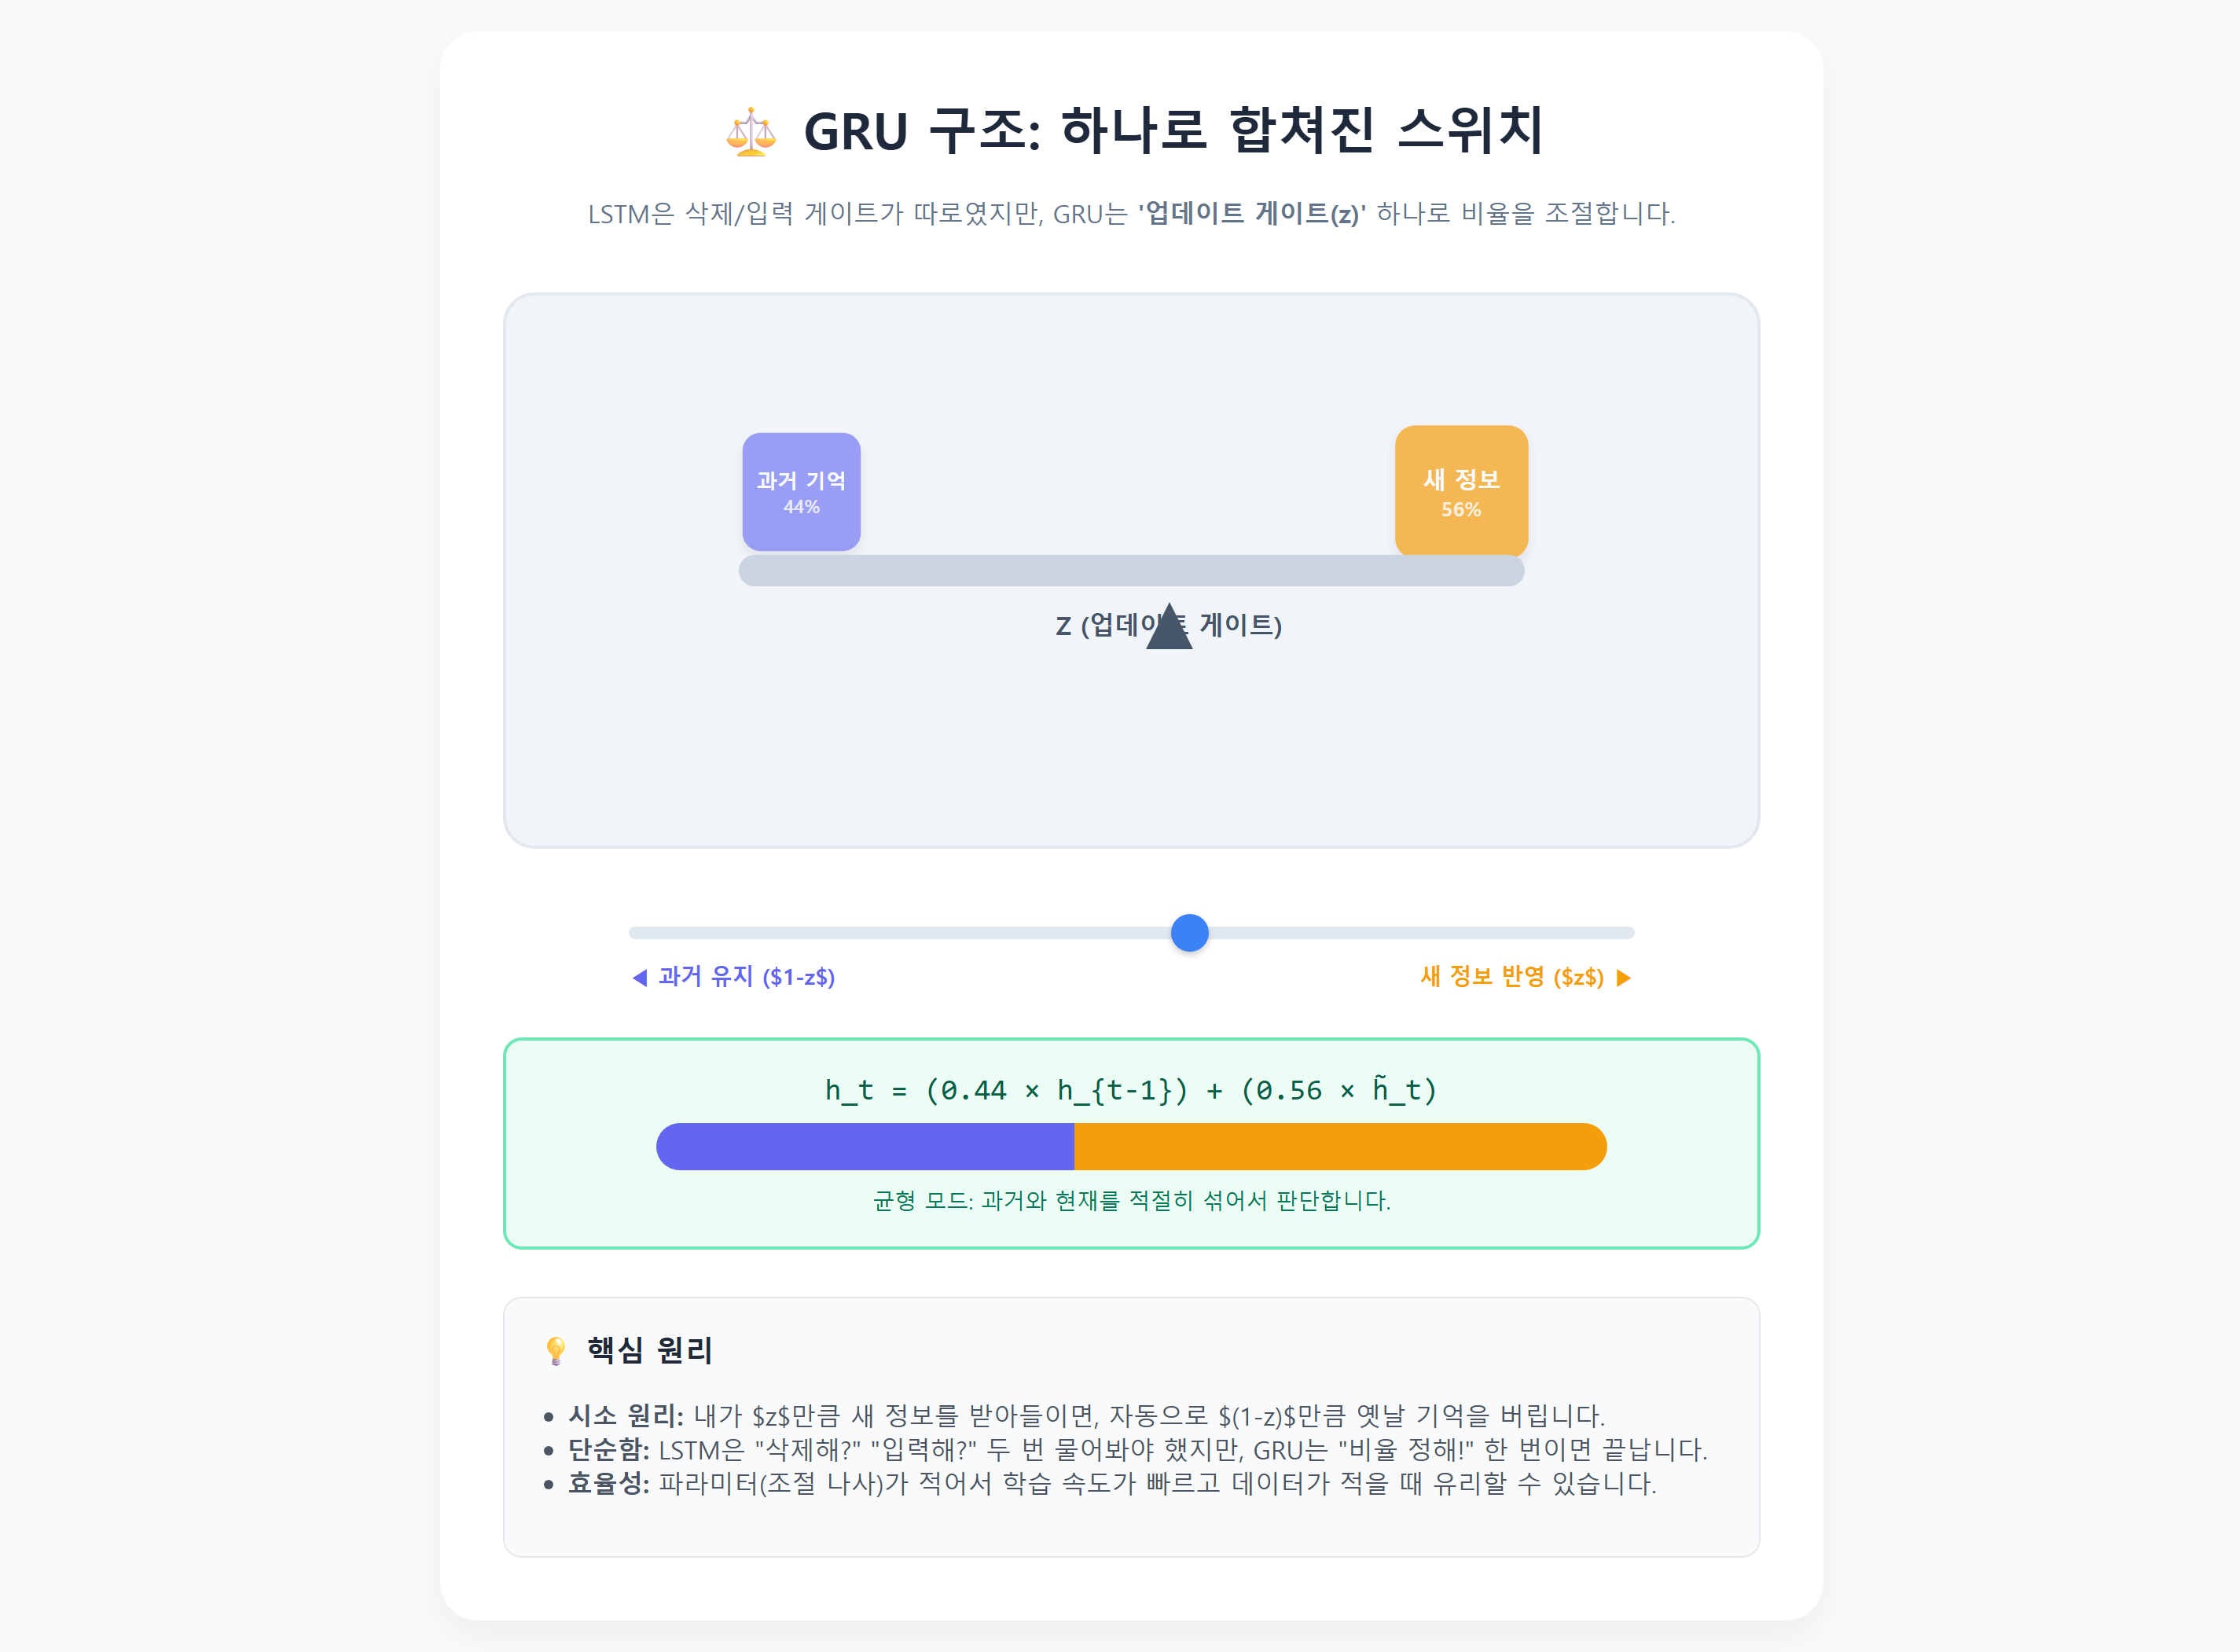

In [39]:
#gru 신경망 훈련하기

model_gru = keras.Sequential()
model_gru.add(keras.layers.Input(shape=(100,)))
model_gru.add(keras.layers.Embedding(500, 16))
model_gru.add(keras.layers.GRU(8, dropout=0.2))
model_gru.add(keras.layers.Dense(1, activation='sigmoid'))

In [40]:
model_gru.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 8)              │           624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,633 (33.72 KB)

 Trainable params: 8,633 (33.72 KB)

 Non-trainable params: 0 (0.00 B)

GRU 셀에는 3개의 작은 셀이 있음.        
작은셀 = 입력과 은닉 상태에 곱하는 가중치, 절편이 있음      
- 입력에 곱하는 가중치 = 16 X 8 = 128개     
- 은닉에 곱하는 가중치 = 8 X 8 = 64개       
따라서, 128 + 64 + 8 = 200개 


In [41]:
model_gru.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
checkpoint_cb=keras.callbacks.ModelCheckpoint('best-gru-model.keras', save_best_only=True)
early_stopping_cb=keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
history = model_gru.fit(train_seq, train_target, epochs=100, batch_size=64, validation_data=(val_seq, val_target), callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100


313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.5905 - loss: 0.6569 - val_accuracy: 0.7756 - val_loss: 0.4826
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.7750 - loss: 0.4778 - val_accuracy: 0.7770 - val_loss: 0.4707
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.7933 - loss: 0.4473 - val_accuracy: 0.7754 - val_loss: 0.4774
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.7947 - loss: 0.4408 - val_accuracy: 0.7718 - val_loss: 0.4712
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.8010 - loss: 0.4348 - val_accuracy: 0.7964 - val_loss: 0.4370
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.8087 - loss: 0.4252 - val_accuracy: 0.7944 - val_loss: 0.4374
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.8037 - loss: 0.4281 - val_accuracy: 0.7858 - val_loss: 0.4559
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.8112 - loss: 0.4171 - val_

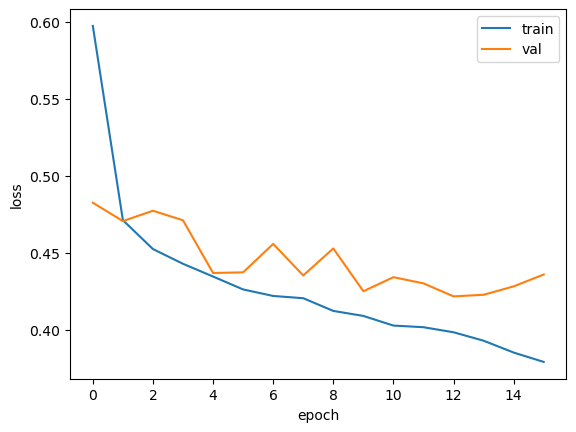

In [42]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()